# 04 — Frozen Lake + Exploration
**Week 3 | RL Fundamentals**

First contact with **Gymnasium**. We run various policies on Frozen Lake and measure performance — no learning yet, just understanding the environment and the exploration-exploitation trade-off.

In [1]:
# Install gymnasium if needed
try:
    import gymnasium as gym
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'gymnasium', '-q'])
    import gymnasium as gym

import numpy as np
import matplotlib.pyplot as plt
print('Gymnasium version:', gym.__version__)

Gymnasium version: 1.3.0


In [2]:
env = gym.make('FrozenLake-v1', is_slippery=False)
print(f"Observation space: {env.observation_space}  ({env.observation_space.n} states)")
print(f"Action space:      {env.action_space}  (0=L, 1=D, 2=R, 3=U)")
print(f"\nTransition model for state 0, action 1 (DOWN):")
for prob, next_s, reward, done in env.unwrapped.P[0][1]:
    print(f"  P={prob:.2f} -> state {next_s}, reward={reward}, done={done}")

Observation space: Discrete(16)  (16 states)
Action space:      Discrete(4)  (0=L, 1=D, 2=R, 3=U)

Transition model for state 0, action 1 (DOWN):
  P=1.00 -> state 4, reward=0, done=False


## 1. Random Policy Baseline

In [3]:
def evaluate_policy(env, policy_fn, n_episodes=1000, max_steps=200):
    wins = 0
    returns = []
    for _ in range(n_episodes):
        s, _ = env.reset()
        ep_return = 0
        for _ in range(max_steps):
            a = policy_fn(s)
            s, r, terminated, truncated, _ = env.step(a)
            ep_return += r
            if terminated or truncated:
                if r == 1.0: wins += 1
                break
        returns.append(ep_return)
    return wins / n_episodes, np.mean(returns)

random_win, random_ret = evaluate_policy(env, lambda s: env.action_space.sample())
print(f"Random policy:  win rate={random_win:.2%}, avg return={random_ret:.4f}")

Random policy:  win rate=1.30%, avg return=0.0130


## 2. Fixed Directional Policy
Manually specify the best deterministic path.

In [4]:
# Hand-crafted policy for 4x4 non-slippery FrozenLake (actions: 0=L,1=D,2=R,3=U)
# Map: SFFF / FHFH / FFFH / HFFG
hand_policy = [
    1, 2, 1, 0,   # row 0
    1, 0, 1, 0,   # row 1 (H at pos 5,7)
    2, 2, 1, 0,   # row 2
    0, 2, 2, 0,   # row 3 (H at pos 12, G at 15)
]
hand_win, hand_ret = evaluate_policy(env, lambda s: hand_policy[s])
print(f"Hand policy:    win rate={hand_win:.2%}, avg return={hand_ret:.4f}")

Hand policy:    win rate=100.00%, avg return=1.0000


## 3. ε-greedy Policy with Learned Bias
Start with a 'smart' action bias and add exploration noise.

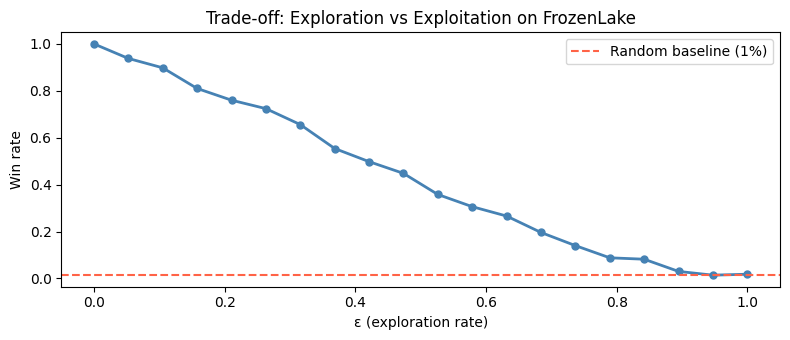

In [5]:
fig, ax = plt.subplots(figsize=(8, 3.5))
eps_values = np.linspace(0, 1, 20)
results = []
for eps in eps_values:
    def eps_hand(s, eps=eps):
        if np.random.rand() < eps:
            return env.action_space.sample()
        return hand_policy[s]
    w, _ = evaluate_policy(env, eps_hand, n_episodes=500)
    results.append(w)
ax.plot(eps_values, results, color='steelblue', linewidth=2, marker='o', markersize=5)
ax.axhline(random_win, color='tomato', linestyle='--', label=f'Random baseline ({random_win:.0%})')
ax.set_xlabel('ε (exploration rate)'); ax.set_ylabel('Win rate')
ax.set_title('Trade-off: Exploration vs Exploitation on FrozenLake')
ax.legend(); plt.tight_layout(); plt.show()

## 4. Inspect the MDP Transitions

In [6]:
# Show how slippery=True changes things
env_slip = gym.make('FrozenLake-v1', is_slippery=True)
slip_win, _ = evaluate_policy(env_slip, lambda s: hand_policy[s])
print(f"Hand policy on SLIPPERY lake: win rate={slip_win:.2%}")
print("\n(Our deterministic policy fails on a stochastic environment!)")

Hand policy on SLIPPERY lake: win rate=4.00%

(Our deterministic policy fails on a stochastic environment!)


## ✅ Exercises
1. Try the 8×8 FrozenLake map (`map_name='8x8'`). Does the hand-crafted policy still work? Why not?
2. Plot win rate vs number of evaluation episodes for the random policy. How many episodes do you need for a stable estimate?
3. **Challenge**: write a systematic policy for the slippery lake — one that avoids dangerous edges. Test it.

In [7]:
env_8x8 = gym.make('FrozenLake-v1', map_name='8x8', is_slippery=False)
print(f"8x8 states: {env_8x8.observation_space.n}, actions: {env_8x8.action_space.n}")

# Hand policy designed for 4x4 won't index 64 states correctly
try:
    w_8x8, _ = evaluate_policy(env_8x8, lambda s: hand_policy[s], n_episodes=500)
    print(f"4x4 hand policy on 8x8: win rate = {w_8x8:.2%}")
except Exception as e:
    print(f"Error: {e}")

# Random baseline on 8x8
w_rand_8x8, _ = evaluate_policy(env_8x8, lambda s: env_8x8.action_space.sample())
print(f"Random policy on 8x8:   win rate = {w_rand_8x8:.2%}")
print("\nWhy it fails: the 4x4 hand policy only covers states 0-15.")
print("8x8 has 64 states with different hole positions — needs a new hand policy.")

8x8 states: 64, actions: 4
Error: list index out of range
Random policy on 8x8:   win rate = 0.40%

Why it fails: the 4x4 hand policy only covers states 0-15.
8x8 has 64 states with different hole positions — needs a new hand policy.


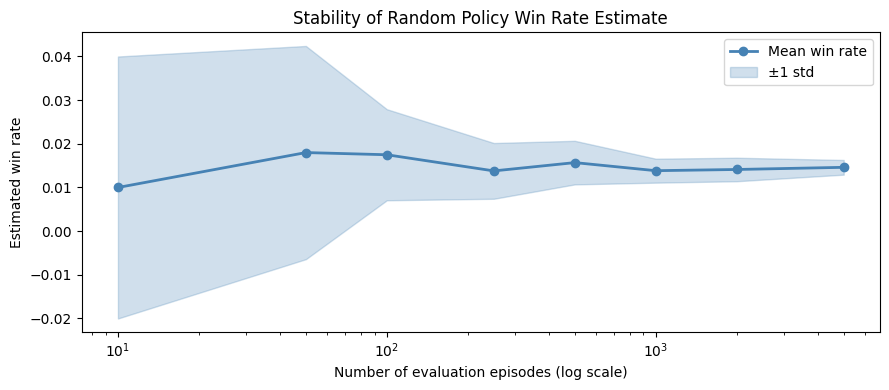

~500-1000 episodes gives a stable estimate (std < 1-2%).


In [8]:
episode_counts = [10, 50, 100, 250, 500, 1000, 2000, 5000]
n_repeats = 20  # repeat each estimate to show variance

fig, ax = plt.subplots(figsize=(9, 4))
means, stds = [], []
for n_ep in episode_counts:
    estimates = []
    for _ in range(n_repeats):
        w, _ = evaluate_policy(env, lambda s: env.action_space.sample(), n_episodes=n_ep)
        estimates.append(w)
    means.append(np.mean(estimates))
    stds.append(np.std(estimates))

means, stds = np.array(means), np.array(stds)
ax.plot(episode_counts, means, color='steelblue', linewidth=2, marker='o', label='Mean win rate')
ax.fill_between(episode_counts, means-stds, means+stds, alpha=0.25, color='steelblue', label='±1 std')
ax.set_xscale('log')
ax.set_xlabel('Number of evaluation episodes (log scale)')
ax.set_ylabel('Estimated win rate')
ax.set_title('Stability of Random Policy Win Rate Estimate')
ax.legend(); plt.tight_layout(); plt.show()
print("~500-1000 episodes gives a stable estimate (std < 1-2%).")

In [9]:
env_slip2 = gym.make('FrozenLake-v1', is_slippery=True)

# Strategy: hug the bottom edge then go right
# Avoid top rows where holes are reachable from slipping
# 4x4 map: SFFF / FHFH / FFFH / HFFG
# Safer path: go down column 0 first, then right along row 3
safe_policy_slip = [
    1, 2, 1, 0,   # row 0: go down, or right if forced
    1, 1, 1, 1,   # row 1: go down (away from holes at 5,7)
    2, 2, 2, 1,   # row 2: go right across bottom safe zone
    2, 2, 2, 0,   # row 3: go right to goal (hole at 12)
]

w_safe, _ = evaluate_policy(env_slip2, lambda s: safe_policy_slip[s], n_episodes=2000)
w_rand_slip, _ = evaluate_policy(env_slip2, lambda s: env_slip2.action_space.sample(), n_episodes=2000)
w_hand_slip, _ = evaluate_policy(env_slip2, lambda s: hand_policy[s], n_episodes=2000)

print(f"Random policy (slippery):       {w_rand_slip:.2%}")
print(f"Original hand policy (slippery):{w_hand_slip:.2%}")
print(f"Safe edge policy (slippery):    {w_safe:.2%}")
print("\nKey idea: on slippery lake, prefer paths along walls (walls catch slips)")
print("and avoid cells adjacent to holes. No deterministic policy achieves 100%.")

Random policy (slippery):       0.95%
Original hand policy (slippery):3.25%
Safe edge policy (slippery):    3.10%

Key idea: on slippery lake, prefer paths along walls (walls catch slips)
and avoid cells adjacent to holes. No deterministic policy achieves 100%.
